<div style="background-color: #fce1ea;  
            border-radius: 20px;  
            padding: 25px;  
            text-align: center;    
            font-family: 'Courier New', monospace;">
  <h1 style="font-size: 42px;">CMG Exploratory Data Analysis (EDA)</h1>
  <p style="font-size: 16px; margin-top: 18px;">
    In this notebook, we explore the CMG dataset to understand the dynamics of blood glucose 
    and insulin in a person with type 1 diabetes. We will analyze meals, insulin doses and glucose measurements to uncover patterns and relationships in the data.
  </p>
  <h2 style="margin-top: 25px; font-size: 24px;">This Notebook Covers:</h2>
  <ul style="text-align: left; display: inline-block; font-size: 15px; margin-top: 8px;">
    <li>Monthly Glucose Profile</li>
    <li>Distribution of glucose throughout the day</li>
    <li>Daily min, max, and average glucose values</li>
    <li>Correlations: meals vs glucose spikes</li>
    <li>Average Basal Insulin by Hour</li>
    <li>Daily Average Glucose and Carbohydrate Intake</li>
    <li>Key Performance Indicators (KPI): average glucose, number of hypo/hyperglycemic events</li>
  </ul>
</div>


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid") 

glucose_df = pd.read_csv('../data/processed/Glucose_concentration.csv').drop_duplicates()
glucose_df['Time'] = pd.to_datetime(glucose_df['Time'])
glucose_df['Date'] = glucose_df['Time'].dt.normalize()
glucose_df['Hour'] = glucose_df['Time'].dt.hour

meal_df = pd.read_csv('../data/processed/Meal.csv')
meal_df['Time'] = pd.to_datetime(meal_df['Time'])
meal_df['Date'] = meal_df['Time'].dt.normalize()

insulin_df = pd.read_csv('../data/processed/Insulin_infusion.csv')
insulin_df['Time'] = pd.to_datetime(insulin_df['Time'])
insulin_df['Date'] = insulin_df['Time'].dt.date
insulin_df['Hour'] = insulin_df['Time'].dt.hour


<div style="background-color: #ffffff;  
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Glucose Levels Over Time
  </h2>

  <hr style="border: none; 
             height: 2px; 
             background-color: #f4a7b9; 
             margin-top: 5px; 
             margin-bottom: 15px;">

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444; 
            text-align: justify;">
    The chart shows glucose measurements throughout July.
Pink bars represent glucose concentrations at each time point, while the red dashed line indicates the overall average glucose level for the month.
  </p>
</div>


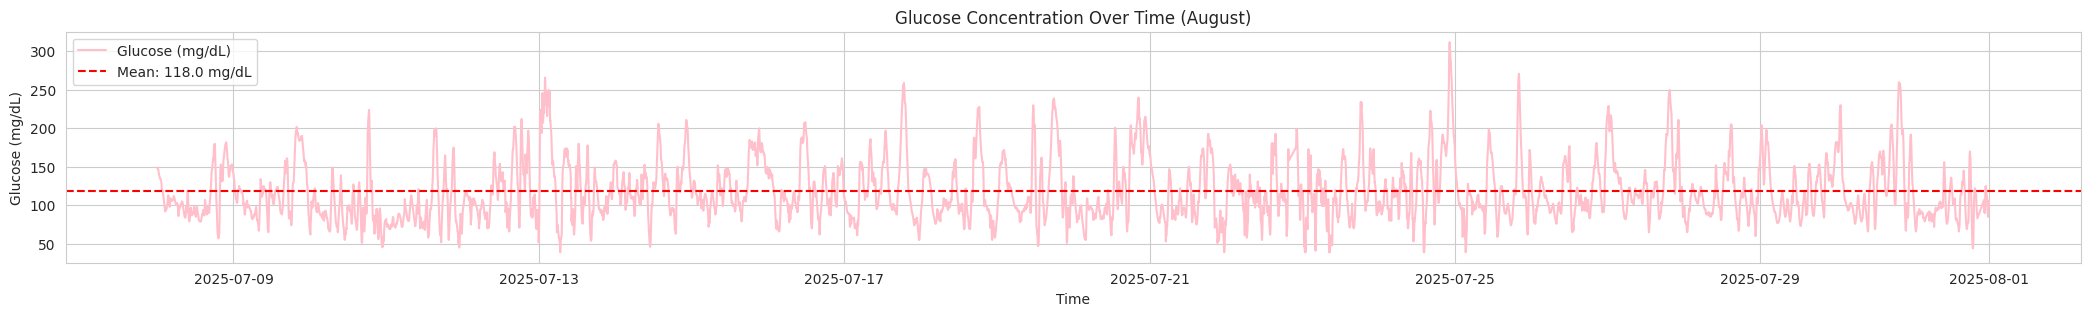

In [2]:
month_df = glucose_df[glucose_df['Time'].dt.month == 7]

plt.figure(figsize=(26,3))
sns.lineplot(data=month_df, x='Time', y='Conc', label='Glucose (mg/dL)', color='pink')

month_mean_glucose = month_df['Conc'].mean()
plt.axhline(month_mean_glucose, color='red', linestyle='--', label=f'Mean: {month_mean_glucose:.1f} mg/dL')

plt.xlabel('Time')
plt.ylabel('Glucose (mg/dL)')
plt.title('Glucose Concentration Over Time (August)')
plt.legend()
plt.show()


<div style="background-color: #ffffff;  
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Conclusions
  </h2>

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444;">
            Glucose levels in July were quite variable, with significant spikes reaching up to 250 mg/dL, highlighting periods of hyperglycemia.
</p>
</div>


<div style="background-color: #ffffff;  
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Distribution of Glucose Levels Throughout the Day
  </h2>

  <hr style="border: none; 
             height: 2px; 
             background-color: #f4a7b9; 
             margin-top: 5px; 
             margin-bottom: 15px;">

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444; 
            text-align: justify;">
    The chart shows how glucose levels vary across different hours of the day.  
    Average glucose was calculated for each hour (0:00–23:00) to observe daily patterns and identify times of highest and lowest values.
  </p>
</div>


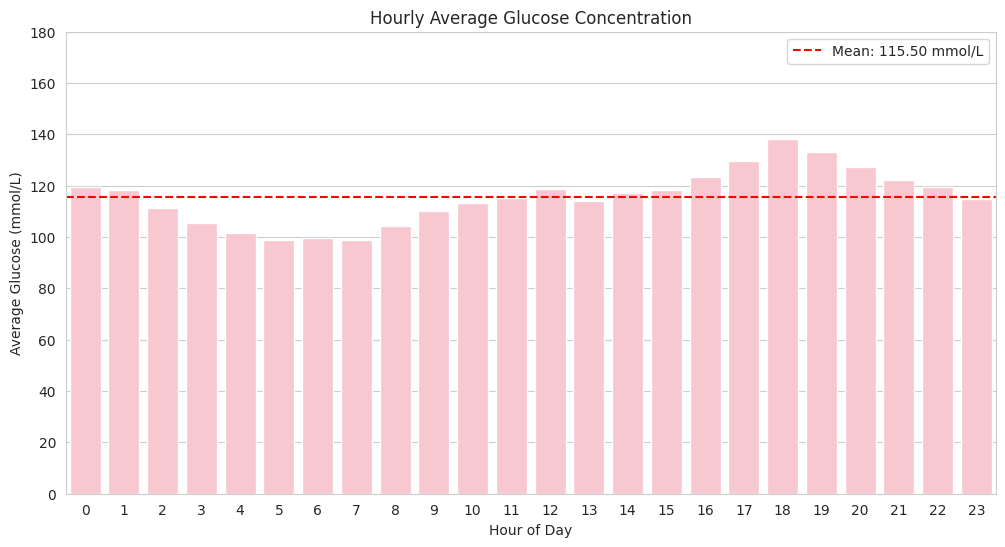

In [3]:
hourly_glucose = glucose_df.groupby('Hour', as_index=False)['Conc'].mean()
plt.figure(figsize=(12,6))
sns.barplot(data=hourly_glucose, x='Hour', y='Conc', color='Pink')
mean_glucose = glucose_df['Conc'].mean()

plt.axhline(mean_glucose, color='red', linestyle='--', label=f'Mean: {mean_glucose:.2f} mmol/L')
plt.xlabel('Hour of Day')
plt.ylabel('Average Glucose (mmol/L)')
plt.title('Hourly Average Glucose Concentration')
plt.xticks(range(0,24)) 
plt.legend()
plt.ylim(0,180)
plt.show()


<div style="background-color: #ffffff; 
            padding: 25px;  
            font-family: 'Courier New', monospace;">
  
  <h2 style="margin-top: 0; 
             font-size: 24px; 
             text-align: left; 
             color: #333;">Conclusions</h2>
  
  
  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444;">
    Glucose levels show a clear daily rhythm — lowest in the morning and peaking in the evening.
  </p>
</div>


<div style="background-color: #ffffff;   
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Daily Minimum and Maximum Glucose Levels
  </h2>

  <hr style="border: none; 
             height: 2px; 
             background-color: #f4a7b9; 
             margin-top: 5px; 
             margin-bottom: 15px;">

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444; 
            text-align: justify;">
    The chart illustrates daily minimum and maximum glucose values, showing day-to-day variability in glucose control.  
    This visualization highlights the amplitude of glucose fluctuations.
  </p>
</div>


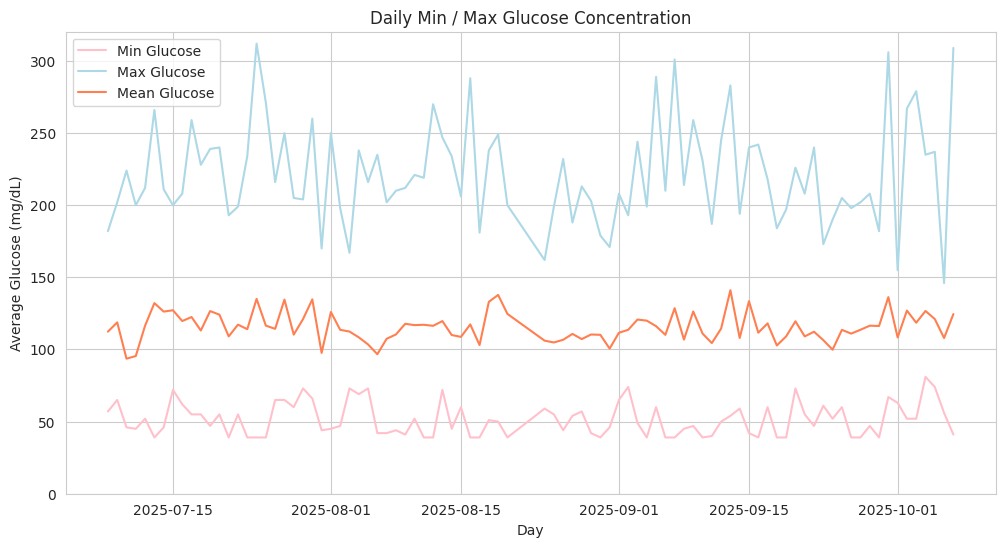

In [4]:
min_daily_glucose = glucose_df.groupby('Date', as_index=False)['Conc'].min()
max_daily_glucose = glucose_df.groupby('Date', as_index=False)['Conc'].max()
mid_daily_glucose = glucose_df.groupby('Date', as_index=False)['Conc'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(data=min_daily_glucose, x='Date', y='Conc', label='Min Glucose', color='pink')
sns.lineplot(data=max_daily_glucose, x='Date', y='Conc', label='Max Glucose', color='lightblue')
sns.lineplot(data=mid_daily_glucose, x='Date', y='Conc', label='Mean Glucose', color='coral')

plt.xlabel('Day')
plt.ylabel('Average Glucose (mg/dL)')
plt.title('Daily Min / Max Glucose Concentration')
plt.legend()
plt.ylim(0,320)
plt.show()


<div style="background-color: #ffffff;  
            padding: 25px;  
            font-family: 'Courier New', monospace;">
  
  <h2 style="margin-top: 0; 
             font-size: 24px; 
             text-align: left; 
             color: #333;">Conclusions</h2>
  
  
  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444;">
    Daily glucose shows high variability in maximum values, while minimums and the mean remain relatively stable. This suggests stable baseline glucose with occasional peaks that may need monitoring.
  </p>
</div>


<div style="background-color: #ffffff;   
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Glucose Levels with Meal Times
  </h2>

  <hr style="border: none; 
             height: 2px; 
             background-color: #f4a7b9; 
             margin-top: 5px; 
             margin-bottom: 15px;">

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444; 
            text-align: justify;">
    The chart shows glucose levels throughout the day with meal times highlighted.  
    Vertical lines indicate the timing of breakfast, lunch, and dinner.  
    Darker lines represent meals with higher carbohydrate (CHO) content.
    This visualization helps to observe how glucose responds after each meal and to identify periods of spikes or stability.
  </p>
</div>


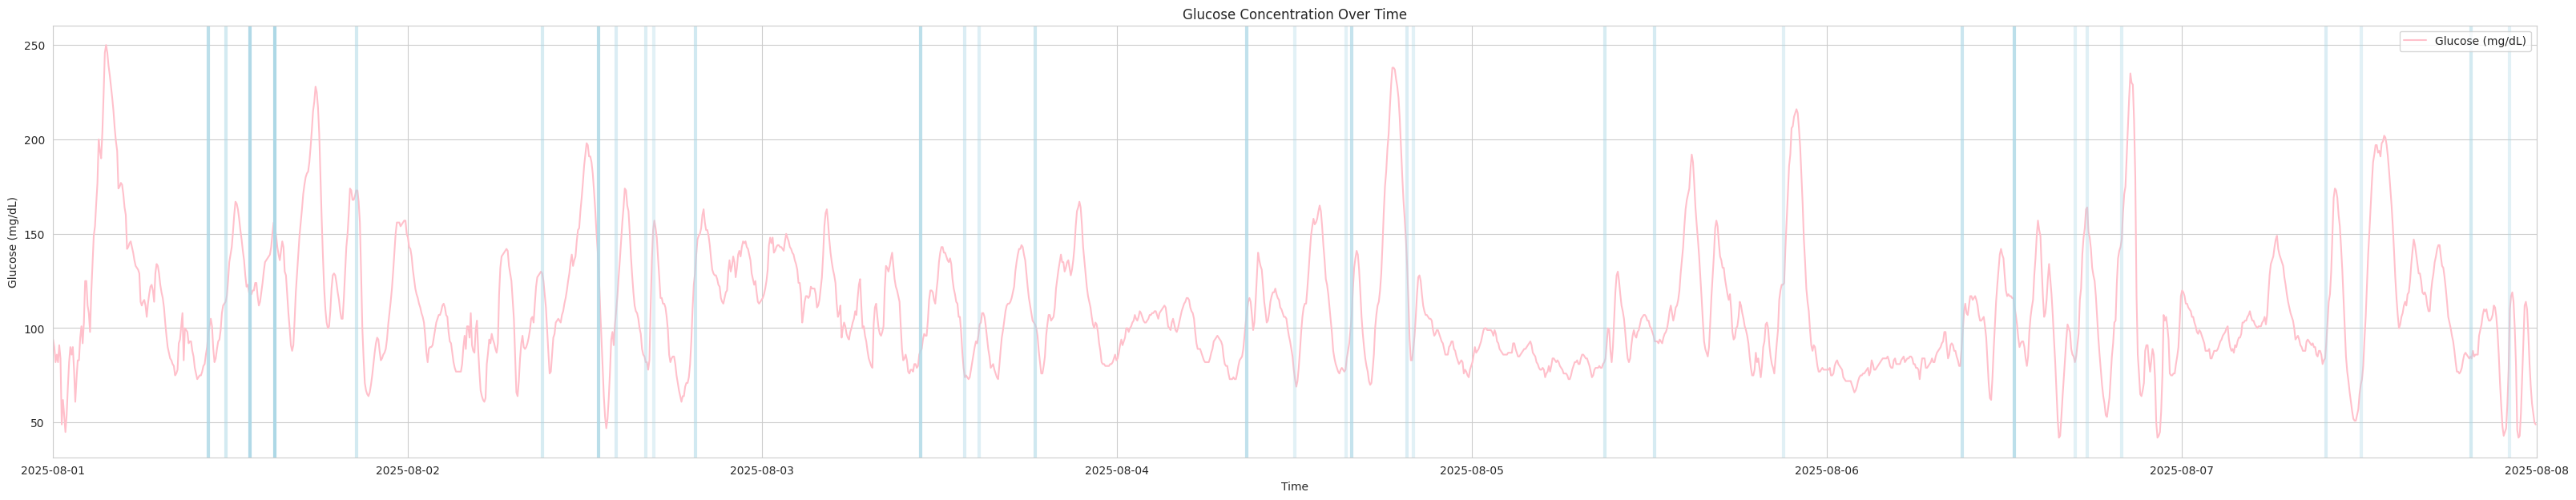

In [5]:
one_week_august_df = glucose_df[(glucose_df['Time'].dt.month == 8) &
                                (glucose_df['Time'].dt.day >= 1) & 
                                (glucose_df['Time'].dt.day < 8)]

norm_cho = (meal_df['CHO'] - meal_df['CHO'].min()) / (meal_df['CHO'].max() - meal_df['CHO'].min())

plt.figure(figsize=(40,7))

sns.lineplot(data=one_week_august_df, x='Time', y='Conc', label='Glucose (mg/dL)', color='Pink')
plt.xlim(pd.Timestamp('2025-08-01'), pd.Timestamp('2025-08-08'))

for meal_time, alpha in zip(meal_df['Time'], norm_cho):
    plt.axvline(x=meal_time, color='lightblue', linestyle='-', alpha=0.3 + 0.7*alpha, linewidth=3)

plt.xlabel('Time')
plt.ylabel('Glucose (mg/dL)')
plt.title('Glucose Concentration Over Time')
plt.legend()
plt.show()


<div style="background-color: #ffffff;  
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Conclusions
  </h2>

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444; 
            text-align: justify;">
    Glucose levels show noticeable spikes after meals, sometimes delayed by a few hours.
High-fat and high-protein meals often cause these delayed rises, while early spikes may result from mistimed insulin or meals eaten too soon after dosing.
  </p>
</div>


<div style="background-color: #ffffff;   
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Average Basal Insulin by Hour (24h)
  </h2>

  <hr style="border: none; 
             height: 2px; 
             background-color: #f4a7b9; 
             margin-top: 5px; 
             margin-bottom: 15px;">

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444; 
            text-align: justify;">
    The chart shows the average basal insulin delivered for each hour of the day (0:00–23:00).  
    Hourly averages were calculated to reveal daily patterns in basal dosing and to identify periods with higher or lower basal rates (units/hour).  
  </p>
</div>


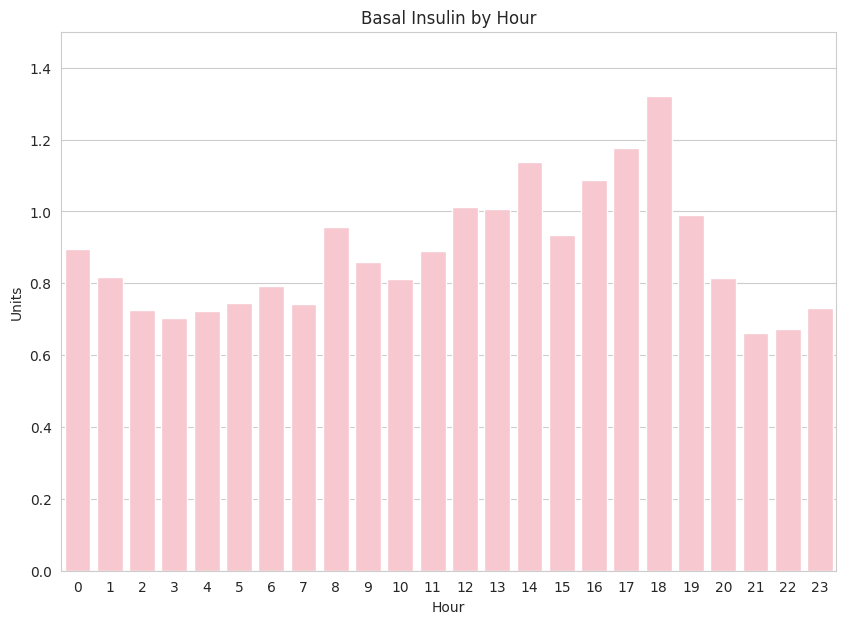

In [6]:
insulin_daily_hourly_df = insulin_df.groupby(['Date','Hour'], as_index=False)['Units'].sum()
insulin_hourly_df = insulin_daily_hourly_df.groupby('Hour', as_index=False)['Units'].mean()

plt.figure(figsize=(10,7))
sns.barplot(data=insulin_hourly_df, x='Hour', y='Units', color='Pink')

plt.xlabel('Hour')
plt.ylabel('Units')
plt.ylim(0,1.5)
plt.title('Basal Insulin by Hour')
plt.show()



<div style="background-color: #ffffff;   
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Conclusions
  </h2>

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444;">
            Basal insulin requirements follow a clear daily rhythm, reaching their peak in the evening, falling to a minimum during the night, and gradually increasing again in the early morning hours.
     </p>
</div>


<div style="background-color: #ffffff;  
            padding: 25px;
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Daily Distribution of Glucose Categories
  </h2>

  <hr style="border: none; 
             height: 2px; 
             background-color: #f4a7b9; 
             margin-top: 5px; 
             margin-bottom: 15px;">

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444; 
            text-align: justify;">
    The chart shows the number of glucose measurements classified as hypoglycemia, normoglycemia, and hyperglycemia for each day.  
    This visualization helps identify days with more frequent hypo- or hyperglycemic events and overall daily glucose stability.
  </p>
</div>


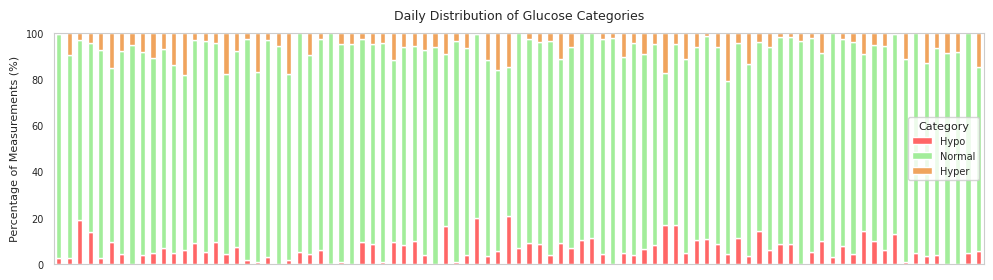

In [7]:
def glucose_category(val):
    if val < 70:
        return 'Hypo'
    elif val >= 180:
        return 'Hyper'
    else:
        return 'Normal'

glucose_df['Category'] = glucose_df['Conc'].apply(glucose_category)

daily_counts = glucose_df.groupby(['Date', 'Category']).size().reset_index(name='Count')
daily_wide = daily_counts.pivot(index='Date', columns='Category', values='Count').fillna(0)
daily_wide = daily_wide[['Hypo', 'Normal', 'Hyper']]  # Hypo na dole, Hyper na górze
daily_percent = daily_wide.div(daily_wide.sum(axis=1), axis=0) * 100

ax = daily_percent.plot(kind='bar', stacked=True, figsize=(12,3), 
                     color={'Hypo':'#ff6666', 'Normal':'#a2ed9a', 'Hyper':'#f0a45d'})
ax.grid(False)
ax.get_xaxis().set_visible(False)
plt.xlabel('Date', fontsize=8)
plt.ylabel('Percentage of Measurements (%)', fontsize=8)
plt.title('Daily Distribution of Glucose Categories', fontsize=9, pad=10)
plt.xticks(rotation=45, fontsize=5)
plt.yticks(fontsize=7)
plt.ylim(0,100)
plt.legend(title='Category', fontsize=7, title_fontsize=8)
plt.show()


<div style="background-color: #ffffff;  
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Conclusions
  </h2>

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444;">
            The daily stacked bar plot shows the proportion of glucose measurements in each category.  
    Most measurements fall within the normal range, while a smaller proportion represents hyperglycemic and hypoglycemic events.  
    This visualization highlights that glucose levels are generally stable, with occasional excursions above or below the target range.
</p>
</div>


<div style="background-color: #ffffff;  
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Daily Average Glucose and Carbohydrate Intake
  </h2>

  <hr style="border: none; 
             height: 2px; 
             background-color: #f4a7b9; 
             margin-top: 5px; 
             margin-bottom: 15px;">

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444; 
            text-align: justify;">
    The chart shows the daily average glucose levels alongside carbohydrate (CHO) intake.  
    Pink bars represent average glucose, while the line indicates CHO consumption.  
    This visualization helps assess how daily carbohydrate intake influences glucose levels.
  </p>
</div>


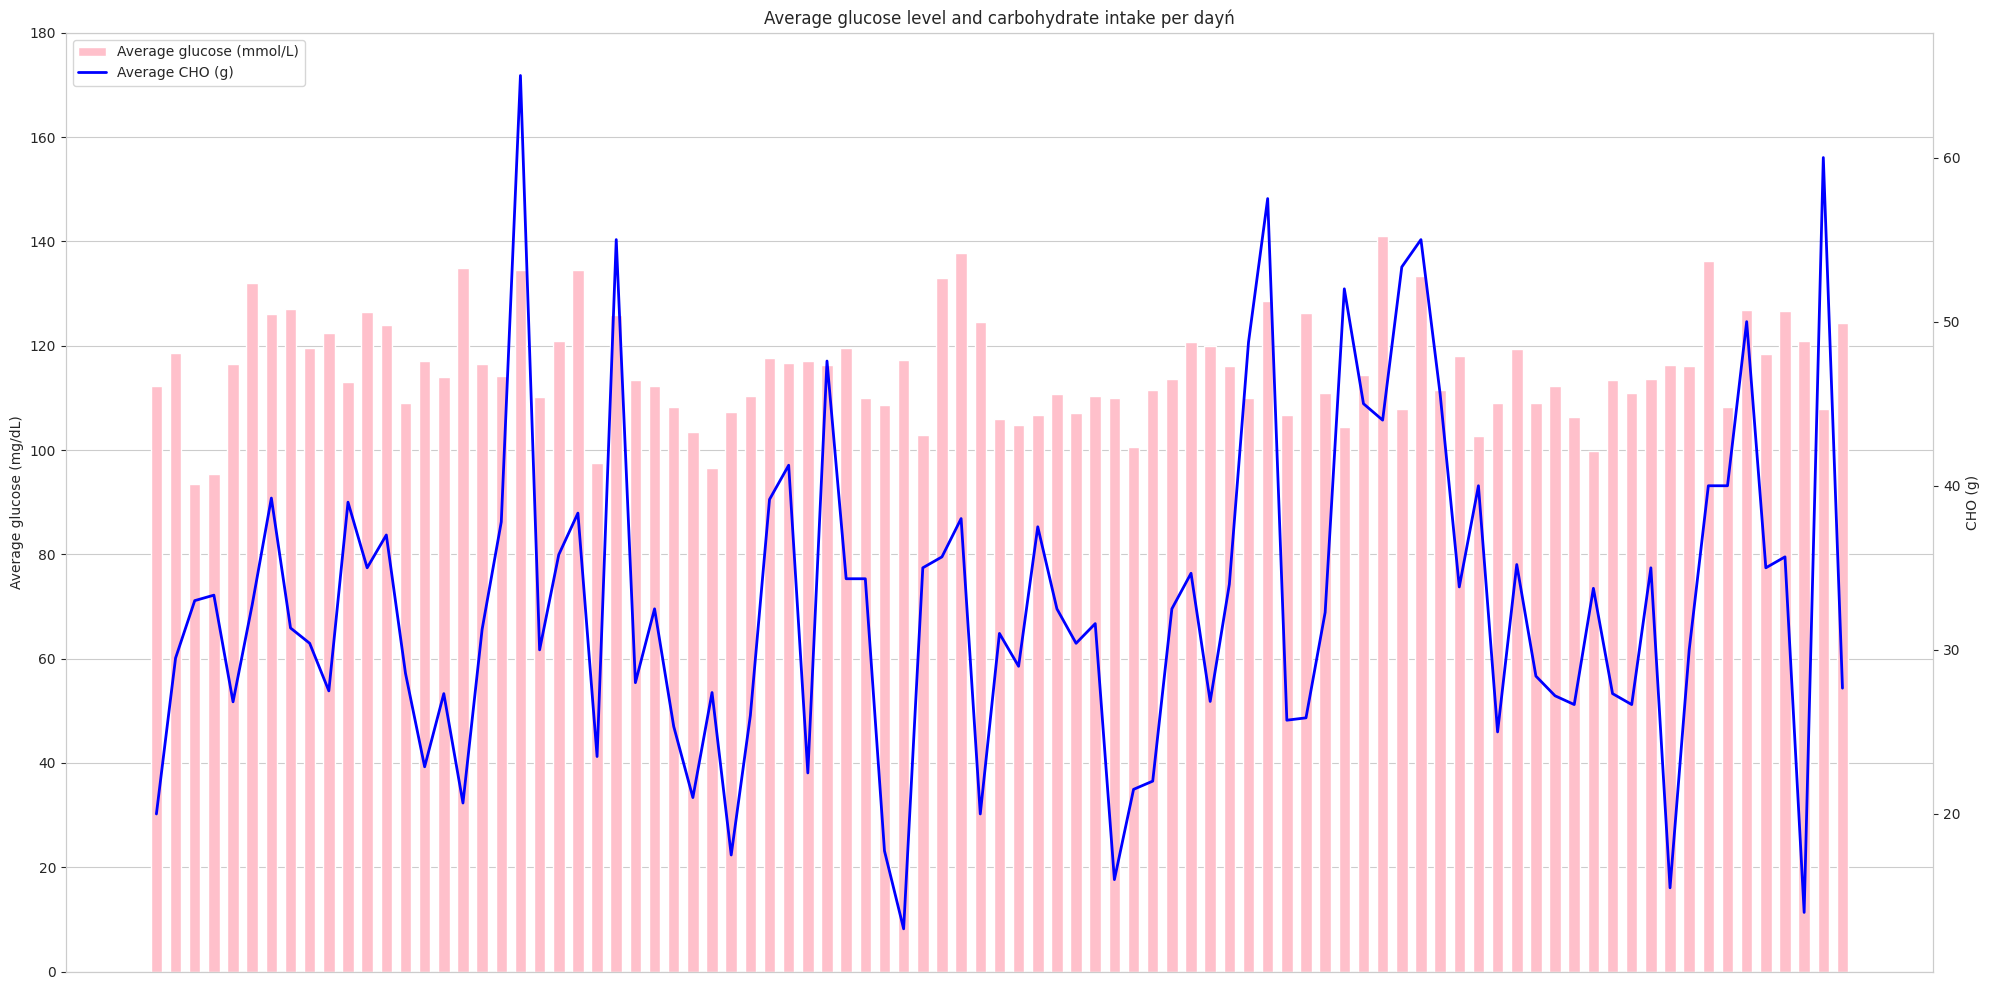

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

glucose_df = glucose_df[~glucose_df['Date'].between('2025-08-21', '2025-08-23')]
meal_df = meal_df[~meal_df['Date'].between('2025-08-21', '2025-08-23')]

daily_glucose = glucose_df.groupby('Date')['Conc'].mean().reset_index()
daily_meal = meal_df.groupby('Date')['CHO'].mean().reset_index()

x = np.arange(len(daily_glucose))

fig, ax1 = plt.subplots(figsize=(20,10))
ax1.bar(x, daily_glucose['Conc'], color='pink', width=0.6, label='Average glucose (mmol/L)')
ax1.set_ylabel('Average glucose (mg/dL)')
ax1.set_ylim(0, max(180, daily_glucose['Conc'].max()*1.2))
ax1.set_xticks(x)
ax1.set_xticklabels([d.strftime('%d-%m') for d in daily_glucose['Date']], rotation=45, fontsize=10)
ax1.get_xaxis().set_visible(False)

ax2 = ax1.twinx()
ax2.plot(x, daily_meal['CHO'], color='blue', linewidth=2, label='Average CHO (g)')
ax2.set_ylabel('CHO (g)')
ax2.grid(False)


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.title("Average glucose level and carbohydrate intake per dayń")
plt.tight_layout()
plt.show()


<div style="background-color: #ffffff;  
            padding: 25px;  
            font-family: 'Courier New', monospace;">

  <h2 style="margin-top: 0; 
             font-size: 22px; 
             text-align: left; 
             color: #333;">
    Conclusions
  </h2>

  <p style="font-size: 16px; 
            margin-top: 10px; 
            color: #444;">
            A clear relationship can be observed: higher carbohydrate intake generally corresponds to higher average glucose levels, highlighting the impact of meal composition on glycemic response.
</p>
</div>
